In [1]:
%pip install -q tqdm torchmetrics optuna
%matplotlib inline

import sys
import random
from pathlib import Path
import copy
import math
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms as T
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
import optuna

# Relative paths (run this script from student_start_pack/)
if "__file__" in globals():
    FILE_DIR = Path(__file__).resolve().parent
else:
    FILE_DIR = Path.cwd()

PROJECT_ROOT = FILE_DIR.parent
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from artbench_local_dataset import load_kaggle_artbench10_splits


import requests, traceback

def notify(msg, title="Notebook"):
    requests.post("https://ntfy.sh/notebookIAGricardo",
        data=msg, headers={"Title": title, "Priority": "high"})



^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


KeyboardInterrupt: 

In [3]:
class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')

set_seed(42)
device = get_device()
print('Device:', device)

Device: cuda


In [4]:
def build_loaders(
    dataset_name='artbench',
    batch_size=128,
    train_limit=10000,
    test_limit=None,
    data_root='IAGdata/artbench-10-python',
    num_workers=0,
):
    image_size = 32
    channels = 3
    
    transform = T.Compose([
        T.Resize(image_size),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])
    
    hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
    train_ds = HFDatasetTorch(hf_ds["train"], transform=transform)
    test_ds = HFDatasetTorch(hf_ds["test"], transform=transform)
    class_names = hf_ds["train"].features["label"].names

    if train_limit is not None:
        train_ds = Subset(train_ds, list(range(min(train_limit, len(train_ds)))))
    if test_limit is not None:
        test_ds = Subset(test_ds, list(range(min(test_limit, len(test_ds)))))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader, channels, image_size, class_names

def denorm(x):
    return (x + 1.0) / 2.0

def show_image_grid(images, channels=3, title='Images', n_show=25, save_path=None):
    images = images[:n_show].detach().cpu()
    images = denorm(images).clamp(0, 1)

    n = images.size(0)
    grid = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(grid, grid, figsize=(grid * 1.6, grid * 1.6))
    axes = np.atleast_2d(axes)

    idx = 0
    for i in range(grid):
        for j in range(grid):
            ax = axes[i, j]
            ax.axis('off')
            if idx < n:
                ax.imshow(images[idx].permute(1, 2, 0))
            idx += 1
    fig.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


@torch.no_grad()
def evaluate_metrics(model, schedule, dataloader, device, num_samples=5000, use_ddim=True, ddim_steps=100):
    is_training = model.training
    model.eval()
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    kid = KernelInceptionDistance(subset_size=100, subsets=50, normalize=True).to(device)

    # Real images
    count = 0
    for real_imgs, _ in dataloader:
        if count >= num_samples: break
        batch = real_imgs[:num_samples-count].to(device)
        batch_01 = denorm(batch).clamp(0, 1)
        fid.update(batch_01, real=True)
        kid.update(batch_01, real=True)
        count += batch.size(0)

    # Generated images
    count = 0
    batch_size = 50
    while count < num_samples:
        current_bs = min(batch_size, num_samples - count)
        if use_ddim:
            fake_imgs = schedule.ddim_sample_loop(model, (current_bs, 3, 32, 32), ddim_steps=ddim_steps)
        else:
            fake_imgs = schedule.p_sample_loop(model, (current_bs, 3, 32, 32))
        fake_01 = denorm(fake_imgs).clamp(0, 1)
        fid.update(fake_01, real=False)
        kid.update(fake_01, real=False)
        count += current_bs

    fid_score = fid.compute().item()
    kid_mean, kid_std = kid.compute()
    fid.reset()
    kid.reset()
    if is_training:
        model.train()
    return fid_score, kid_mean.item(), kid_std.item()

### Diffusion Components

In [5]:
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

class GaussianDiffusion:
    def __init__(self, num_timesteps=1000, beta_schedule='cosine', beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.num_timesteps = num_timesteps
        self.device = device
        
        if beta_schedule == 'cosine':
            self.betas = cosine_beta_schedule(num_timesteps).to(device)
        else:
            self.betas = torch.linspace(beta_start, beta_end, num_timesteps).to(device)
        
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.]).to(device), self.alphas_cumprod[:-1]])
        
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)
        self.posterior_variance = self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)

    def q_sample(self, x_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_0)
        sqrt_alpha_prod = self._get_index(self.sqrt_alphas_cumprod, t, x_0.shape)
        sqrt_one_minus_alpha_prod = self._get_index(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)
        return sqrt_alpha_prod * x_0 + sqrt_one_minus_alpha_prod * noise

    def _get_index(self, tensor, t, x_shape):
        out = tensor.gather(-1, t)
        return out.view(t.shape[0], *((1,) * (len(x_shape) - 1)))

    @torch.no_grad()
    def p_sample_loop(self, model, shape):
        model.eval()
        x = torch.randn(shape, device=self.device)
        for step in reversed(range(self.num_timesteps)):
            t = torch.full((shape[0],), step, device=self.device, dtype=torch.long)
            pred_noise = model(x, t)

            alpha_t = self.alphas[step]
            alpha_bar_t = self.alphas_cumprod[step]
            beta_t = self.betas[step]

            if step > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            x = (1.0 / torch.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * pred_noise) + torch.sqrt(beta_t) * noise
        return x

    @torch.no_grad()
    def ddim_sample_loop(self, model, shape, ddim_steps=100, eta=0.0, x_init=None):
        """DDIM sampling for faster inference (Song et al., 2020)"""
        model.eval()
        # Create sub-sequence of timesteps
        step_size = self.num_timesteps // ddim_steps
        timesteps = list(range(0, self.num_timesteps, step_size))
        timesteps = list(reversed(timesteps))
        
        x = x_init.clone() if x_init is not None else torch.randn(shape, device=self.device)
        
        for i in range(len(timesteps)):
            t_cur = timesteps[i]
            t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else 0
            
            t_batch = torch.full((shape[0],), t_cur, device=self.device, dtype=torch.long)
            pred_noise = model(x, t_batch)
            
            alpha_bar_t = self.alphas_cumprod[t_cur]
            alpha_bar_prev = self.alphas_cumprod[t_prev] if t_prev > 0 else torch.tensor(1.0, device=self.device)
            
            # Predict x_0
            pred_x0 = (x - torch.sqrt(1 - alpha_bar_t) * pred_noise) / torch.sqrt(alpha_bar_t)
            pred_x0 = pred_x0.clamp(-1, 1)
            
            # Compute variance
            sigma = eta * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_prev))
            
            # Direction pointing to x_t
            dir_xt = torch.sqrt(1 - alpha_bar_prev - sigma ** 2) * pred_noise
            
            noise = torch.randn_like(x) if t_cur > 0 else torch.zeros_like(x)
            x = torch.sqrt(alpha_bar_prev) * pred_x0 + dir_xt + sigma * noise
        
        return x

In [6]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class SelfAttention(nn.Module):
    def __init__(self, dim, num_groups=32):
        super().__init__()
        self.norm = nn.GroupNorm(min(num_groups, dim), dim)
        self.qkv = nn.Conv2d(dim, dim * 3, 1)
        self.proj = nn.Conv2d(dim, dim, 1)
        self.scale = dim ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        attn = (q.transpose(-1, -2) @ k) * self.scale
        attn = attn.softmax(dim=-1)
        out = (v @ attn.transpose(-1, -2)).reshape(B, C, H, W)
        return x + self.proj(out)

class ResnetBlock(nn.Module):
    def __init__(self, dim, time_emb_dim, out_dim=None, num_groups=32):
        super().__init__()
        self.out_dim = out_dim or dim
        self.mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, self.out_dim))
        self.conv1 = nn.Conv2d(dim, self.out_dim, 3, padding=1)
        self.conv2 = nn.Conv2d(self.out_dim, self.out_dim, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(num_groups, dim), dim)
        self.norm2 = nn.GroupNorm(min(num_groups, self.out_dim), self.out_dim)
        self.act = nn.SiLU()
        self.shortcut = nn.Conv2d(dim, self.out_dim, 1) if dim != self.out_dim else nn.Identity()

    def forward(self, x, time_emb):
        h = self.conv1(self.act(self.norm1(x)))
        h = h + self.mlp(time_emb)[:, :, None, None]
        h = self.conv2(self.act(self.norm2(h)))
        return self.shortcut(x) + h

class PixelUNet(nn.Module):
    def __init__(self, in_channels=3, model_channels=128, num_groups=32):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalPosEmb(model_channels),
            nn.Linear(model_channels, model_channels * 4),
            nn.SiLU(),
            nn.Linear(model_channels * 4, model_channels * 4),
        )
        time_dim = model_channels * 4
        self.init_conv = nn.Conv2d(in_channels, model_channels, 3, padding=1)
        
        # 32 -> 16
        self.down1_res1 = ResnetBlock(model_channels, time_dim, num_groups=num_groups)
        self.down1_res2 = ResnetBlock(model_channels, time_dim, num_groups=num_groups)
        self.down1_pool = nn.Conv2d(model_channels, model_channels, 3, stride=2, padding=1)
        
        # 16 -> 8 (with attention at 16x16)
        self.down2_res1 = ResnetBlock(model_channels, time_dim, out_dim=model_channels * 2, num_groups=num_groups)
        self.down2_attn = SelfAttention(model_channels * 2, num_groups=num_groups)
        self.down2_res2 = ResnetBlock(model_channels * 2, time_dim, num_groups=num_groups)
        self.down2_pool = nn.Conv2d(model_channels * 2, model_channels * 2, 3, stride=2, padding=1)
        
        # Bottleneck at 8x8 (with attention)
        self.mid_res1 = ResnetBlock(model_channels * 2, time_dim, num_groups=num_groups)
        self.mid_attn = SelfAttention(model_channels * 2, num_groups=num_groups)
        self.mid_res2 = ResnetBlock(model_channels * 2, time_dim, num_groups=num_groups)
        
        # 8 -> 16 (with attention)
        self.up2_upsample = nn.ConvTranspose2d(model_channels * 2, model_channels, 4, stride=2, padding=1)
        self.up2_res1 = ResnetBlock(model_channels * 3, time_dim, out_dim=model_channels, num_groups=num_groups)
        self.up2_attn = SelfAttention(model_channels, num_groups=num_groups)
        self.up2_res2 = ResnetBlock(model_channels, time_dim, num_groups=num_groups)
        
        # 16 -> 32
        self.up1_upsample = nn.ConvTranspose2d(model_channels, model_channels, 4, stride=2, padding=1)
        self.up1_res1 = ResnetBlock(model_channels * 2, time_dim, out_dim=model_channels, num_groups=num_groups)
        self.up1_res2 = ResnetBlock(model_channels, time_dim, num_groups=num_groups)
        
        self.out_norm = nn.GroupNorm(min(num_groups, model_channels), model_channels)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(model_channels, in_channels, 3, padding=1)
        
    def forward(self, x, t):
        t_emb = self.time_embed(t)
        
        h_init = self.init_conv(x)
        
        # Down 1: 32 -> 16
        h1 = self.down1_res1(h_init, t_emb)
        h1 = self.down1_res2(h1, t_emb)
        h1_pool = self.down1_pool(h1)
        
        # Down 2: 16 -> 8 (with attention)
        h2 = self.down2_res1(h1_pool, t_emb)
        h2 = self.down2_attn(h2)
        h2 = self.down2_res2(h2, t_emb)
        h2_pool = self.down2_pool(h2)
        
        # Bottleneck at 8x8
        h_mid = self.mid_res1(h2_pool, t_emb)
        h_mid = self.mid_attn(h_mid)
        h_mid = self.mid_res2(h_mid, t_emb)
        
        # Up 2: 8 -> 16
        h_up2 = torch.cat([self.up2_upsample(h_mid), h2], dim=1)
        h_up2 = self.up2_res1(h_up2, t_emb)
        h_up2 = self.up2_attn(h_up2)
        h_up2 = self.up2_res2(h_up2, t_emb)
        
        # Up 1: 16 -> 32
        h_up1 = torch.cat([self.up1_upsample(h_up2), h1], dim=1)
        h_up1 = self.up1_res1(h_up1, t_emb)
        h_up1 = self.up1_res2(h_up1, t_emb)
        
        return self.out_conv(self.out_act(self.out_norm(h_up1)))

In [7]:
class EMA:
    """Exponential Moving Average of model weights (decay ~0.9999)"""
    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.shadow = copy.deepcopy(model)
        self.shadow.eval()
        for p in self.shadow.parameters():
            p.requires_grad_(False)

    def update(self, model):
        with torch.no_grad():
            for s_param, m_param in zip(self.shadow.parameters(), model.parameters()):
                s_param.data.mul_(self.decay).add_(m_param.data, alpha=1.0 - self.decay)

    def get_model(self):
        return self.shadow


def save_checkpoint(model, ema, history, checkpoint_path, params):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        'model_state': model.state_dict(),
        'ema_state': ema.get_model().state_dict(),
        'params': params,
        'history': history
    }, checkpoint_path)
    print(f"✅ Checkpoint saved to {checkpoint_path}")


def train_diffusion(
    model, 
    loader, 
    schedule, 
    epochs=20, 
    lr=2e-4, 
    ema_decay=0.999, 
    grad_clip=1.0, 
    print_progress=True,
    val_loader=None,
    checkpoint_dir=None,
    save_interval=10,
    num_fid_samples=1500,
    model_params=None,
    trial=None # Added for Optuna pruning
):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    ema = EMA(model, decay=ema_decay)
    history = {'mse_loss': [], 'fid': []}
    model.train()

    best_fid = float('inf')

    if checkpoint_dir:
        checkpoint_dir = Path(checkpoint_dir)
        checkpoint_dir.mkdir(parents=True, exist_ok=True)
        (checkpoint_dir / 'samples').mkdir(exist_ok=True)

    for epoch in range(epochs):
        running = 0.0
        n_batches = 0
        for x, _ in tqdm(loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False, disable=not print_progress):
            x = x.to(device)
            t = torch.randint(0, schedule.num_timesteps, (x.size(0),), device=device).long()
            noise = torch.randn_like(x)
            x_t = schedule.q_sample(x_0=x, t=t, noise=noise)

            opt.zero_grad()
            pred_noise = model(x_t, t)
            loss = F.mse_loss(pred_noise, noise)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ema.update(model)

            running += loss.item()
            n_batches += 1

        avg_loss = running / max(n_batches, 1)
        history['mse_loss'].append(avg_loss)

        status_str = f'Epoch {epoch + 1:02d}/{epochs} | loss: {avg_loss:.6f}'

        # Optuna Pruning: Report progress and check if we should stop
        if trial is not None:
            trial.report(avg_loss, epoch)
            if trial.should_prune():
                if print_progress:
                    print(f" Trial pruned at epoch {epoch+1}")
                raise optuna.TrialPruned()

        # Periodic Monitoring
# Visual Samples, FID, and Checkpoints
        if (epoch + 1) % save_interval == 0 or epoch == 0 or epoch == epochs - 1:
            # 1. Visual Samples (using EMA model and DDIM)
            if checkpoint_dir:
                with torch.no_grad():
                    ema_model = ema.get_model()
                    ema_model.eval()
                    samples = schedule.ddim_sample_loop(ema_model, (25, 3, 32, 32), ddim_steps=50)
                    sample_path = checkpoint_dir / 'samples' / f'epoch_{epoch+1:03d}.png'
                    show_image_grid(samples, channels=3, title=f'Epoch {epoch+1} (EMA/DDIM)', save_path=sample_path)
                    model.train()

            # 2. FID Metrics
            if val_loader:
                ema_model = ema.get_model()
                fid_score, kid_mean, _ = evaluate_metrics(ema_model, schedule, val_loader, device, num_samples=num_fid_samples, ddim_steps=50)
                history['fid'].append({'epoch': epoch + 1, 'fid': fid_score, 'kid': kid_mean})
                status_str += f" | FID: {fid_score:.2f}"
                
                # Save best model based on FID
                if fid_score < best_fid and checkpoint_dir:
                    best_fid = fid_score
                    save_checkpoint(model, ema, history, checkpoint_dir / 'best_fid_model.pt', model_params)
                    if print_progress:
                        print(f"   -> New best FID: {best_fid:.4f}. Saved best_fid_model.pt")

            # 3. Regular Checkpoint
            if checkpoint_dir:
                save_checkpoint(model, ema, history, checkpoint_dir / f'checkpoint_epoch_{epoch+1:03d}.pt', model_params)

        if print_progress:
            print(status_str)

    return history, best_fid, ema

In [8]:
# Load Data
artbench_train_loader, artbench_test_loader, artbench_channels, artbench_image_size, artbench_classes = build_loaders()

Dataset source: kaggle root='c:\Users\ricar\OneDrive\Desktop\Curso\IAG\Projeto\artbench\ArtBench-10'


In [43]:
def objective(trial):
    # Optimizing only the Learning Rate (LR) as per strategy
    lr = trial.suggest_float("lr", 1e-4, 3e-4, log=True)
    
    # Fixed parameters recommended by the professor
    fixed_channels = 128
    fixed_schedule_type = 'cosine'
    
    print(f"\n>>> Trial {trial.number} | LR: {lr:.6f} | Channels: {fixed_channels} | Schedule: {fixed_schedule_type}")

    model = PixelUNet(in_channels=3, model_channels=fixed_channels).to(device)
    schedule = GaussianDiffusion(num_timesteps=1000, beta_schedule=fixed_schedule_type, device=device)
    
    # We use MSE loss for Optuna optimization
    try:
        history, _, _ = train_diffusion(
            model, 
            artbench_train_loader, 
            schedule, 
            epochs=30, 
            lr=lr, 
            print_progress=False,
            save_interval=31,
            trial=trial # Pass the trial for pruning
        )
        return history['mse_loss'][-1]
    except optuna.TrialPruned:
        raise # Re-raise to let Optuna handle it correctly

print("Starting Optuna Study (Optimizing Learning Rate with Pruning)...")
study = optuna.create_study(
    direction="minimize", 
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5) # Start pruning after 5 epochs
)
study.optimize(objective, n_trials=10, gc_after_trial=True)

print(f"\nMelhor LR encontrado: {study.best_params['lr']:.6f}")
print(f"Melhor Loss: {study.best_value:.6f}")

[I 2026-04-20 15:18:11,322] A new study created in memory with name: no-name-b712a645-8501-4759-bdb3-5196de17ca5f


Starting Optuna Study (Optimizing Learning Rate with Pruning)...

>>> Trial 0 | LR: 0.000151 | Channels: 128 | Schedule: cosine


[I 2026-04-20 15:30:51,641] Trial 0 finished with value: 0.06486553288524664 and parameters: {'lr': 0.00015090410414033437}. Best is trial 0 with value: 0.06486553288524664.



>>> Trial 1 | LR: 0.000284 | Channels: 128 | Schedule: cosine


[I 2026-04-20 15:43:42,626] Trial 1 finished with value: 0.06642384143381179 and parameters: {'lr': 0.0002841881747862226}. Best is trial 0 with value: 0.06486553288524664.


...


>>> Trial 8 | LR: 0.000194 | Channels: 128 | Schedule: cosine


[I 2026-04-20 16:38:13,812] Trial 8 pruned. 



>>> Trial 9 | LR: 0.000218 | Channels: 128 | Schedule: cosine


[I 2026-04-20 16:41:19,105] Trial 9 pruned. 



Melhor LR encontrado: 0.000193
Melhor Loss: 0.063978


Re-loading full ArtBench dataset (50k images)...
Dataset source: kaggle root='c:\Users\ricar\OneDrive\Desktop\Curso\IAG\Projeto\artbench\ArtBench-10'


Epoch 1/250:   0%|          | 0/391 [00:00<?, ?it/s]

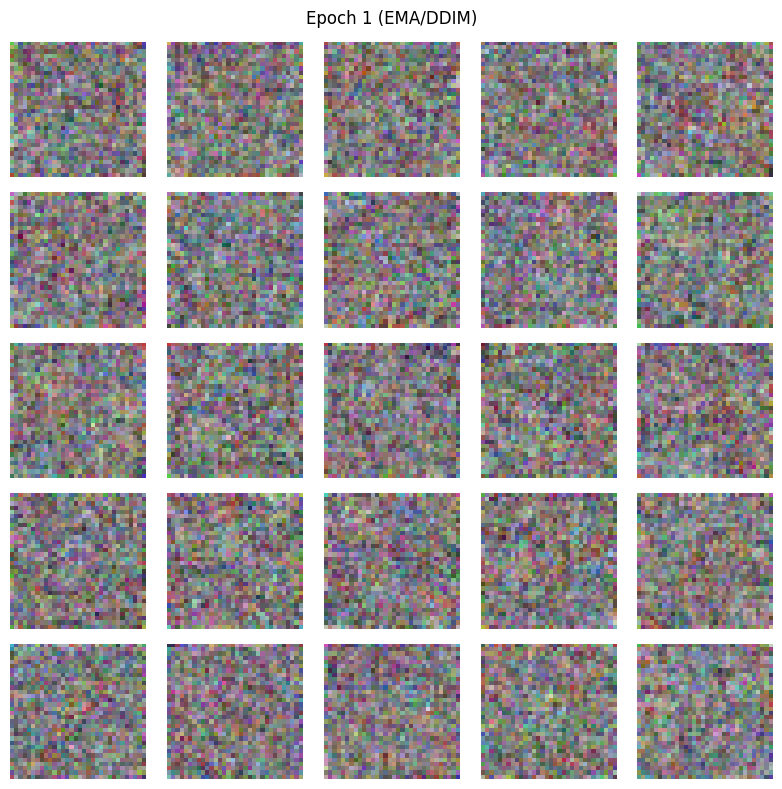

c:\Users\ricar\OneDrive\Desktop\Curso\IAG\Projeto\artbench\genai-env\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 408.1404. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_001.pt
Epoch 01/250 | loss: 0.102979 | FID: 408.14


Epoch 2/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 02/250 | loss: 0.071671


Epoch 3/250:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 8/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 08/250 | loss: 0.064051


Epoch 9/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 09/250 | loss: 0.063954


Epoch 10/250:   0%|          | 0/391 [00:00<?, ?it/s]

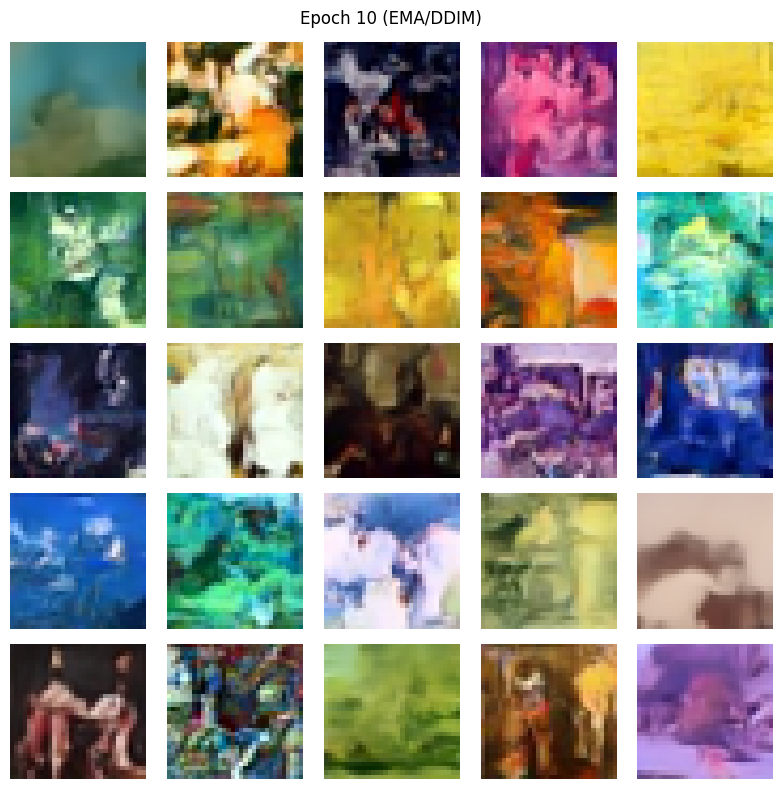

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 97.2082. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_010.pt
Epoch 10/250 | loss: 0.064025 | FID: 97.21


Epoch 11/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 11/250 | loss: 0.064035


Epoch 12/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 12/250 | loss: 0.063199


...

Epoch 18/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 18/250 | loss: 0.061872


Epoch 19/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 19/250 | loss: 0.062122


Epoch 20/250:   0%|          | 0/391 [00:00<?, ?it/s]

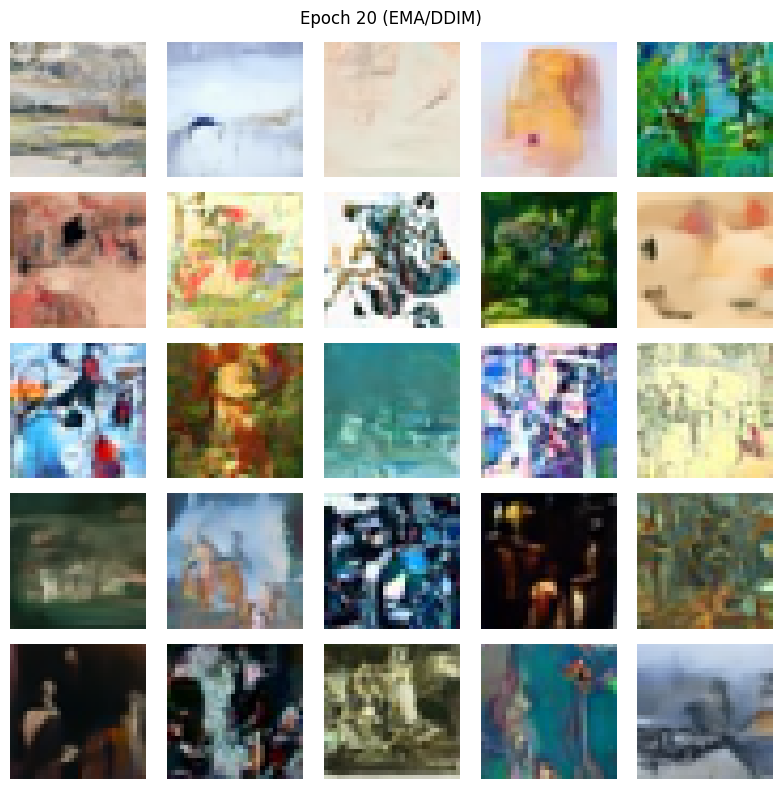

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 66.3902. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_020.pt
Epoch 20/250 | loss: 0.061579 | FID: 66.39


Epoch 21/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 21/250 | loss: 0.061678


Epoch 22/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 22/250 | loss: 0.061749


...

Epoch 28/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 28/250 | loss: 0.061075


Epoch 29/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 29/250 | loss: 0.061483


Epoch 30/250:   0%|          | 0/391 [00:00<?, ?it/s]

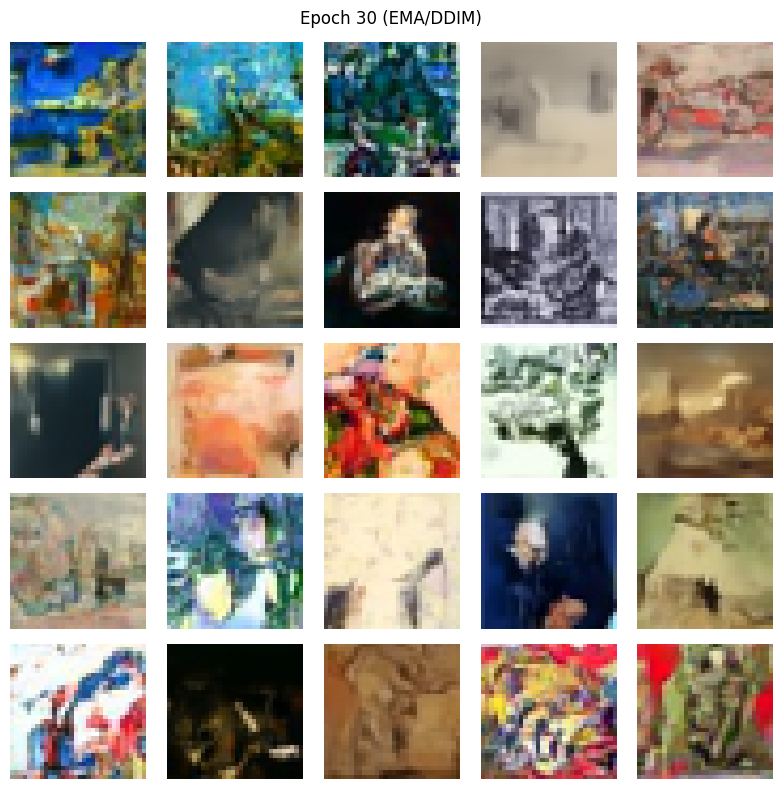

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 58.4759. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_030.pt
Epoch 30/250 | loss: 0.061688 | FID: 58.48


Epoch 31/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 31/250 | loss: 0.060644


Epoch 32/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 32/250 | loss: 0.061146


...

Epoch 38/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 38/250 | loss: 0.061466


Epoch 39/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 39/250 | loss: 0.061210


Epoch 40/250:   0%|          | 0/391 [00:00<?, ?it/s]

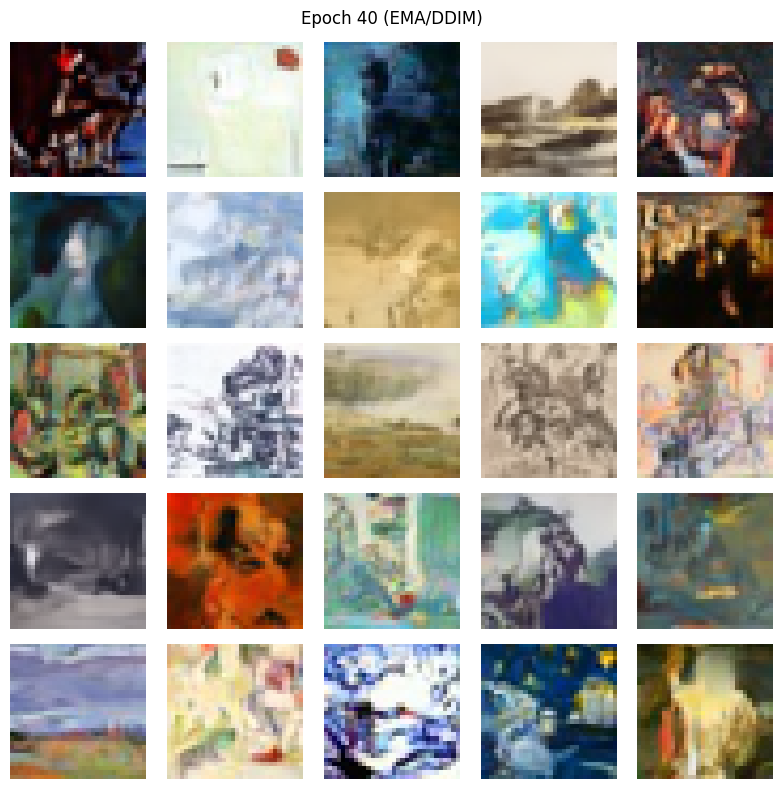

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 55.2822. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_040.pt
Epoch 40/250 | loss: 0.060144 | FID: 55.28


Epoch 41/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 41/250 | loss: 0.060716


Epoch 42/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 42/250 | loss: 0.060969


...

Epoch 48/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 48/250 | loss: 0.060644


Epoch 49/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 49/250 | loss: 0.061159


Epoch 50/250:   0%|          | 0/391 [00:00<?, ?it/s]

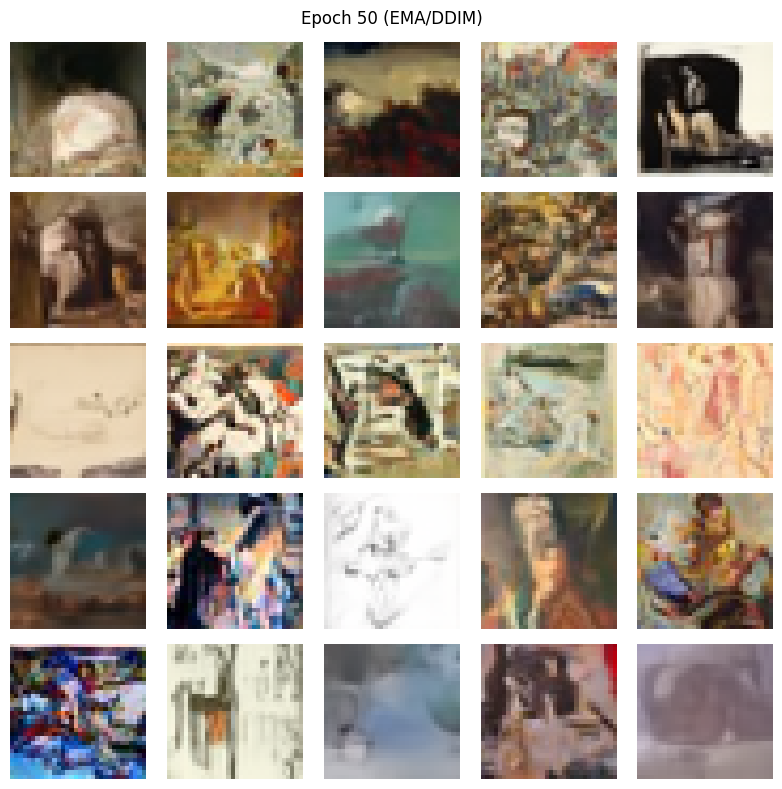

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 53.4947. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_050.pt
Epoch 50/250 | loss: 0.060385 | FID: 53.49


Epoch 51/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 51/250 | loss: 0.060764


Epoch 52/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 52/250 | loss: 0.060786


...

Epoch 58/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 58/250 | loss: 0.060501


Epoch 59/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 59/250 | loss: 0.060027


Epoch 60/250:   0%|          | 0/391 [00:00<?, ?it/s]

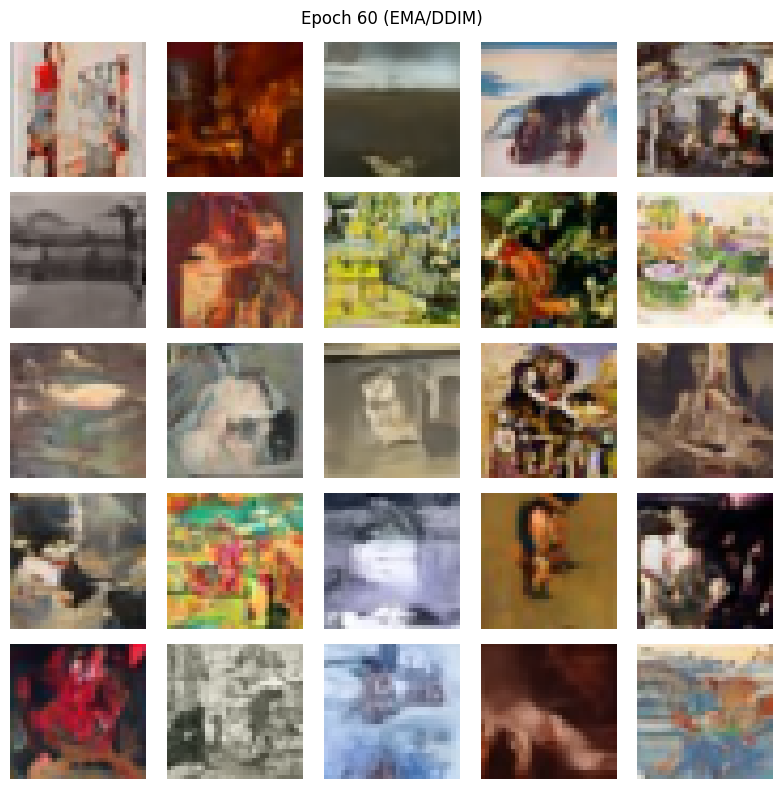

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 51.7533. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_060.pt
Epoch 60/250 | loss: 0.060511 | FID: 51.75


Epoch 61/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 61/250 | loss: 0.059853


Epoch 62/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 62/250 | loss: 0.060030


...

Epoch 68/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 68/250 | loss: 0.060299


Epoch 69/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 69/250 | loss: 0.060188


Epoch 70/250:   0%|          | 0/391 [00:00<?, ?it/s]

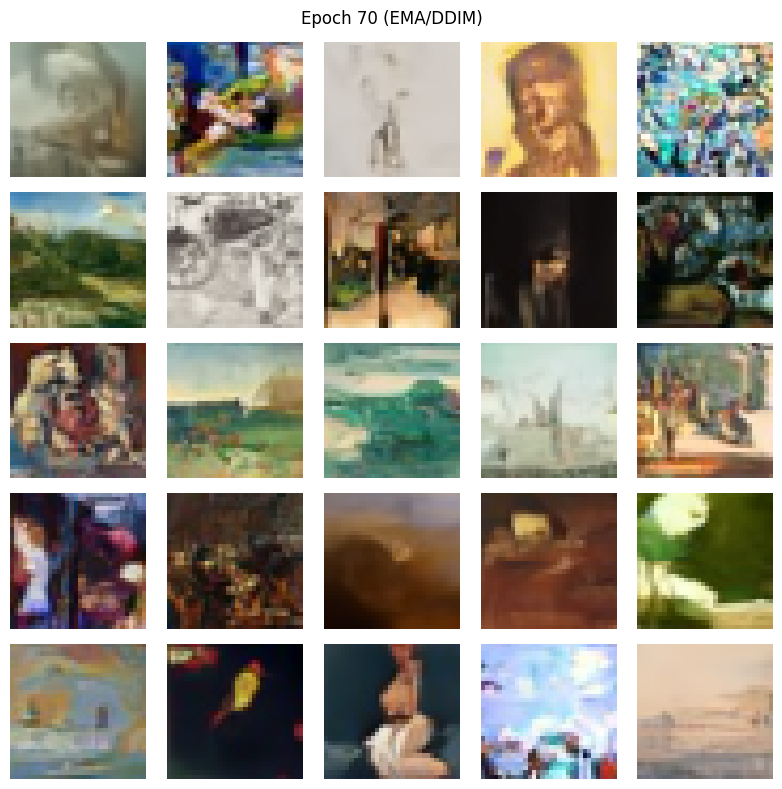

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 49.1789. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_070.pt
Epoch 70/250 | loss: 0.060677 | FID: 49.18


Epoch 71/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 71/250 | loss: 0.060329


Epoch 72/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 72/250 | loss: 0.060150


...

Epoch 78/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 78/250 | loss: 0.060078


Epoch 79/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 79/250 | loss: 0.060133


Epoch 80/250:   0%|          | 0/391 [00:00<?, ?it/s]

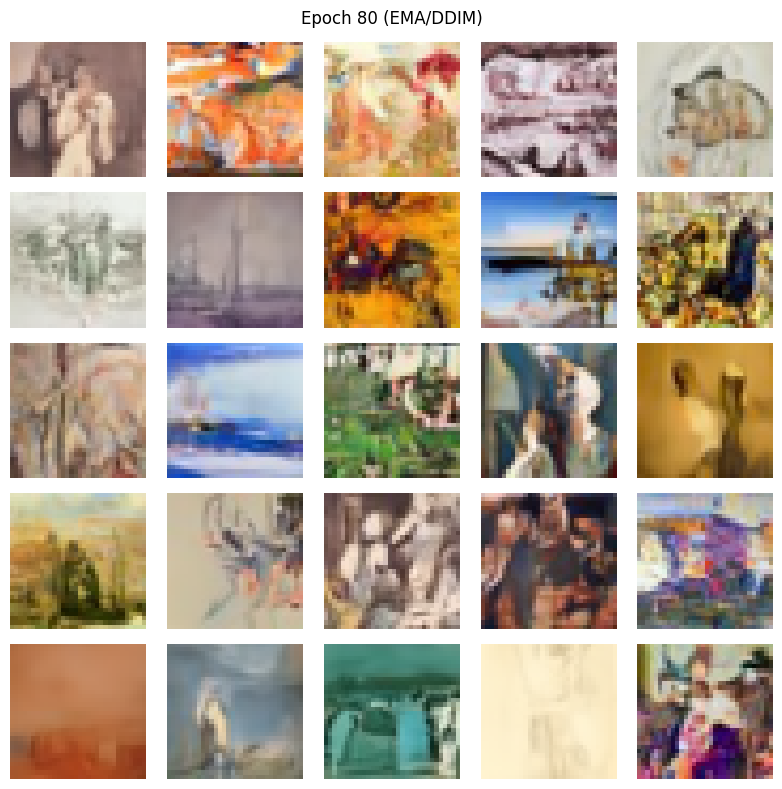

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 49.0732. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_080.pt
Epoch 80/250 | loss: 0.059996 | FID: 49.07


Epoch 81/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 81/250 | loss: 0.059546


Epoch 82/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 82/250 | loss: 0.059963


...

Epoch 88/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 88/250 | loss: 0.059719


Epoch 89/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 89/250 | loss: 0.059867


Epoch 90/250:   0%|          | 0/391 [00:00<?, ?it/s]

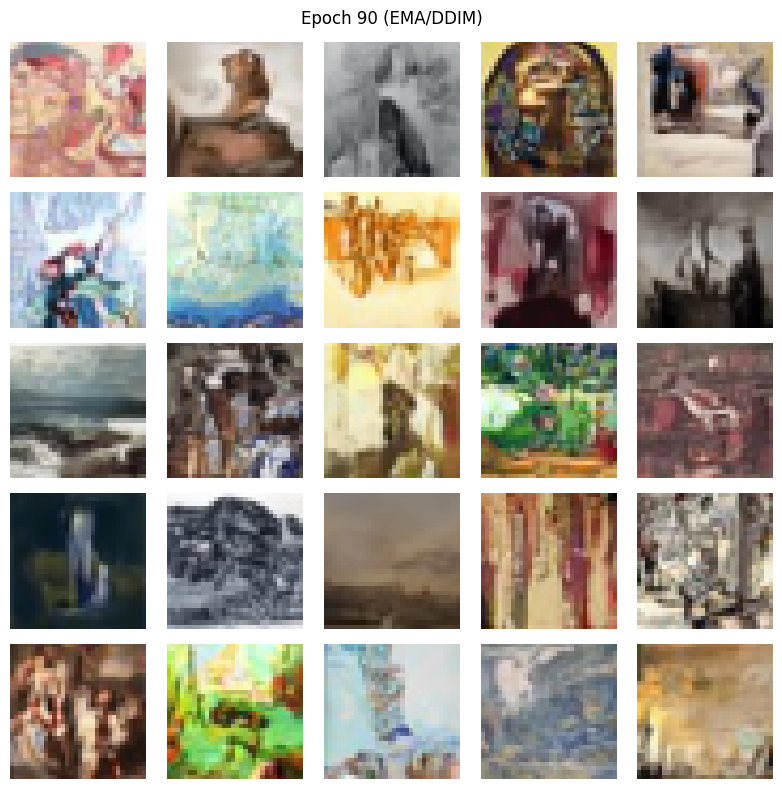

✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_090.pt
Epoch 90/250 | loss: 0.060049 | FID: 49.32


Epoch 91/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 91/250 | loss: 0.060878


Epoch 92/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 92/250 | loss: 0.059468


...

Epoch 98/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 98/250 | loss: 0.059704


Epoch 99/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 99/250 | loss: 0.059631


Epoch 100/250:   0%|          | 0/391 [00:00<?, ?it/s]

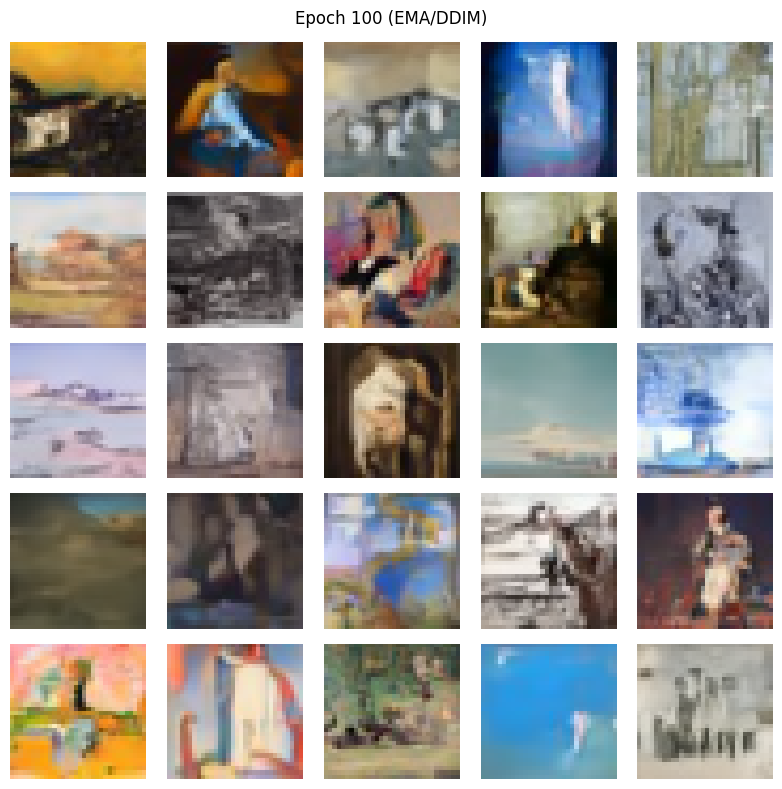

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 47.6715. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_100.pt
Epoch 100/250 | loss: 0.058907 | FID: 47.67


Epoch 101/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 101/250 | loss: 0.059978


Epoch 102/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 102/250 | loss: 0.059948


...

Epoch 108/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 108/250 | loss: 0.059793


Epoch 109/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 109/250 | loss: 0.060657


Epoch 110/250:   0%|          | 0/391 [00:00<?, ?it/s]

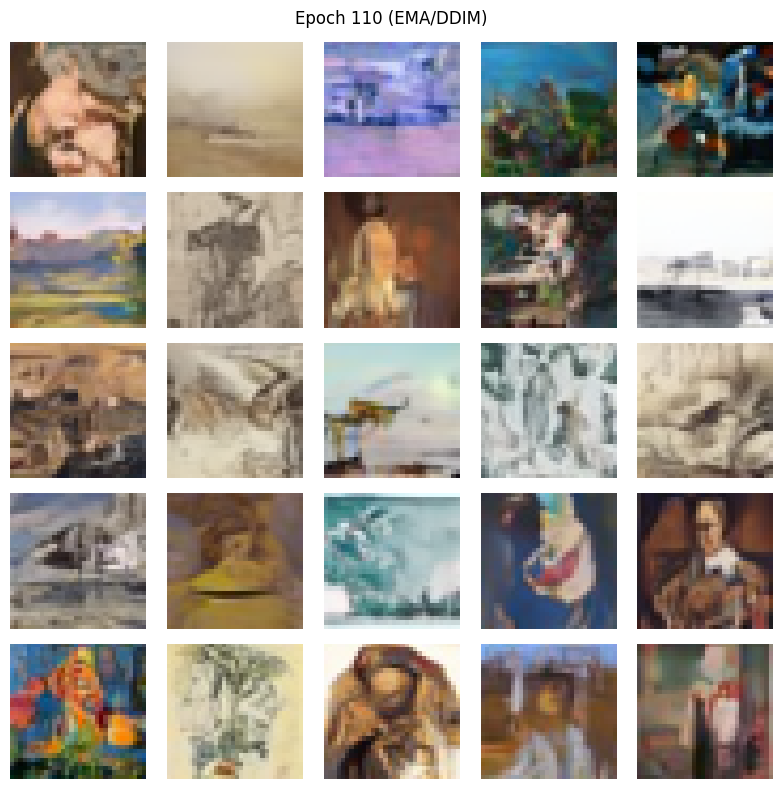

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 46.7590. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_110.pt
Epoch 110/250 | loss: 0.059100 | FID: 46.76


Epoch 111/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 111/250 | loss: 0.059684


Epoch 112/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 112/250 | loss: 0.059409


...

Epoch 118/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 118/250 | loss: 0.060005


Epoch 119/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 119/250 | loss: 0.059411


Epoch 120/250:   0%|          | 0/391 [00:00<?, ?it/s]

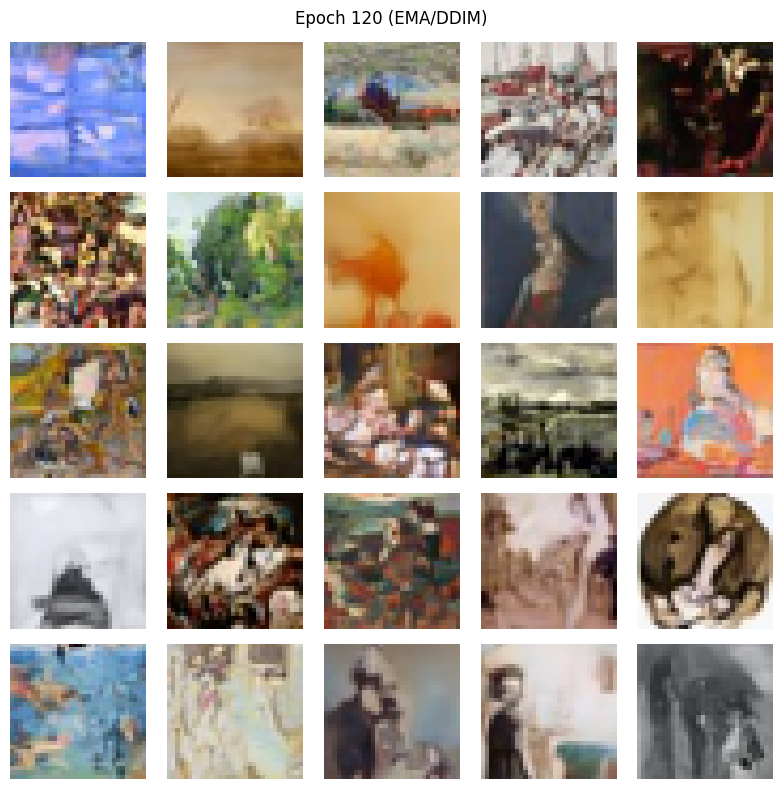

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 46.5505. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_120.pt
Epoch 120/250 | loss: 0.059076 | FID: 46.55


Epoch 121/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 121/250 | loss: 0.059444


Epoch 122/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 122/250 | loss: 0.059640


...

Epoch 128/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 128/250 | loss: 0.059177


Epoch 129/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 129/250 | loss: 0.059823


Epoch 130/250:   0%|          | 0/391 [00:00<?, ?it/s]

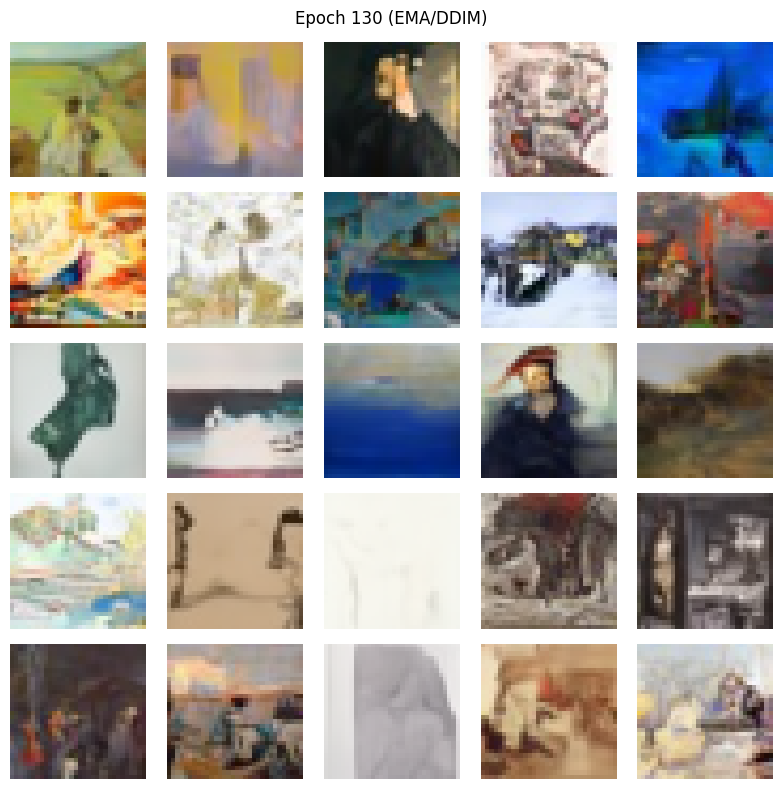

✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_130.pt
Epoch 130/250 | loss: 0.059638 | FID: 46.97


Epoch 131/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 131/250 | loss: 0.059557


Epoch 132/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 132/250 | loss: 0.059562


...

Epoch 138/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 138/250 | loss: 0.059788


Epoch 139/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 139/250 | loss: 0.059301


Epoch 140/250:   0%|          | 0/391 [00:00<?, ?it/s]

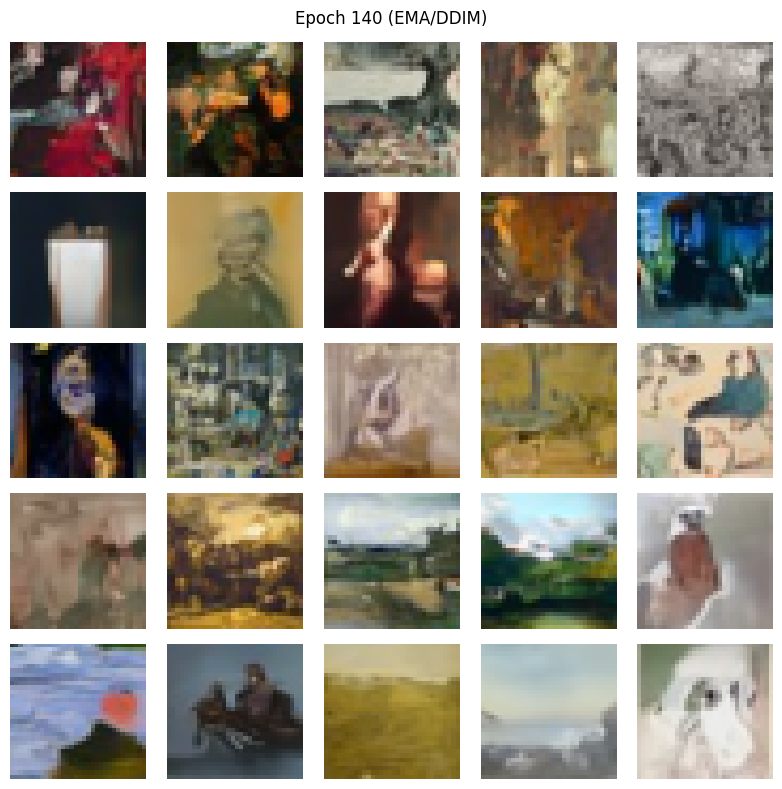

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 45.8279. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_140.pt
Epoch 140/250 | loss: 0.059074 | FID: 45.83


Epoch 141/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 141/250 | loss: 0.059188


Epoch 142/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 142/250 | loss: 0.059622


...

Epoch 148/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 148/250 | loss: 0.059272


Epoch 149/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 149/250 | loss: 0.059023


Epoch 150/250:   0%|          | 0/391 [00:00<?, ?it/s]

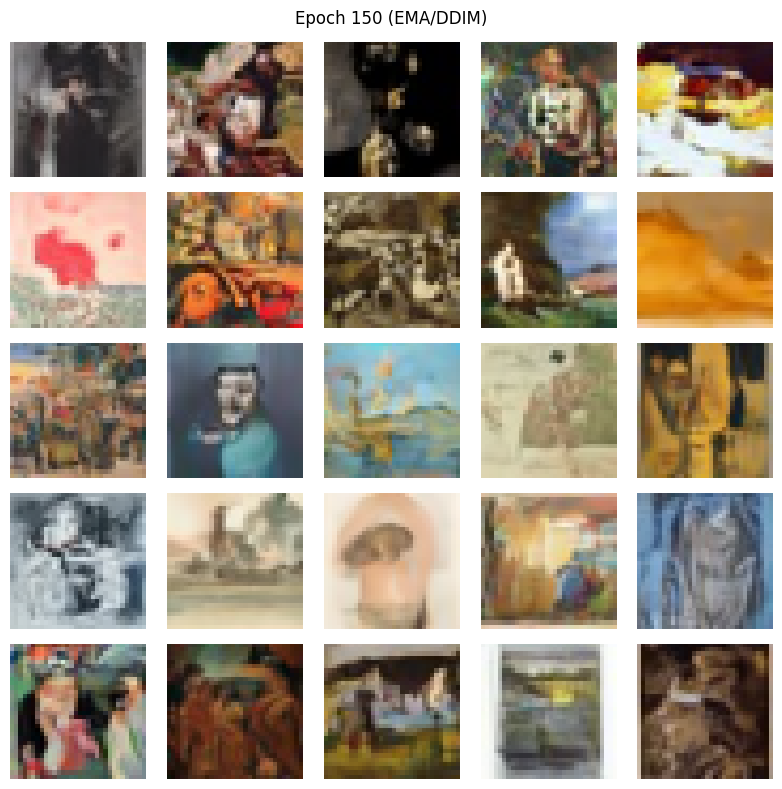

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 45.1339. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_150.pt
Epoch 150/250 | loss: 0.059328 | FID: 45.13


Epoch 151/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 151/250 | loss: 0.058887


Epoch 152/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 152/250 | loss: 0.058987


...

Epoch 158/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 158/250 | loss: 0.059168


Epoch 159/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 159/250 | loss: 0.058870


Epoch 160/250:   0%|          | 0/391 [00:00<?, ?it/s]

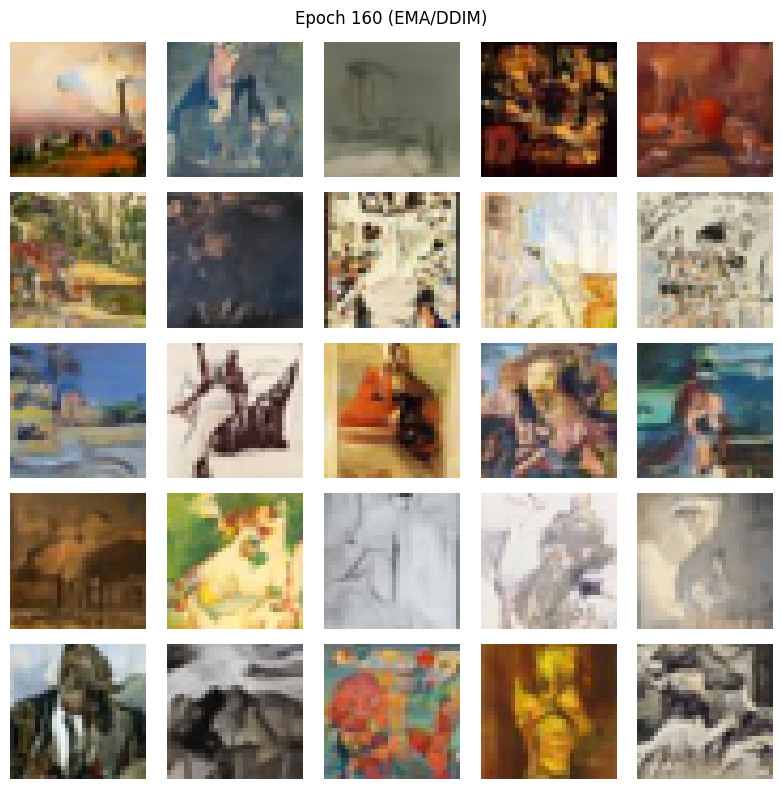

✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_160.pt
Epoch 160/250 | loss: 0.059117 | FID: 47.22


Epoch 161/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 161/250 | loss: 0.059067


Epoch 162/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 162/250 | loss: 0.059191


...

Epoch 168/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 168/250 | loss: 0.058643


Epoch 169/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 169/250 | loss: 0.059055


Epoch 170/250:   0%|          | 0/391 [00:00<?, ?it/s]

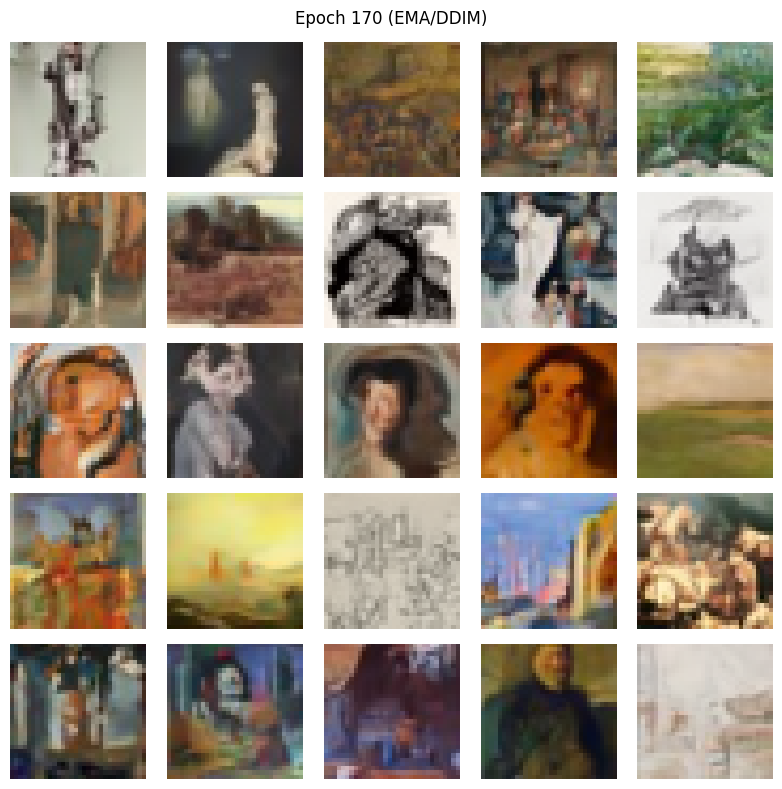

✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_170.pt
Epoch 170/250 | loss: 0.060057 | FID: 45.64


Epoch 171/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 171/250 | loss: 0.058877


Epoch 172/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 172/250 | loss: 0.059258


...

Epoch 178/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 178/250 | loss: 0.059312


Epoch 179/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 179/250 | loss: 0.059284


Epoch 180/250:   0%|          | 0/391 [00:00<?, ?it/s]

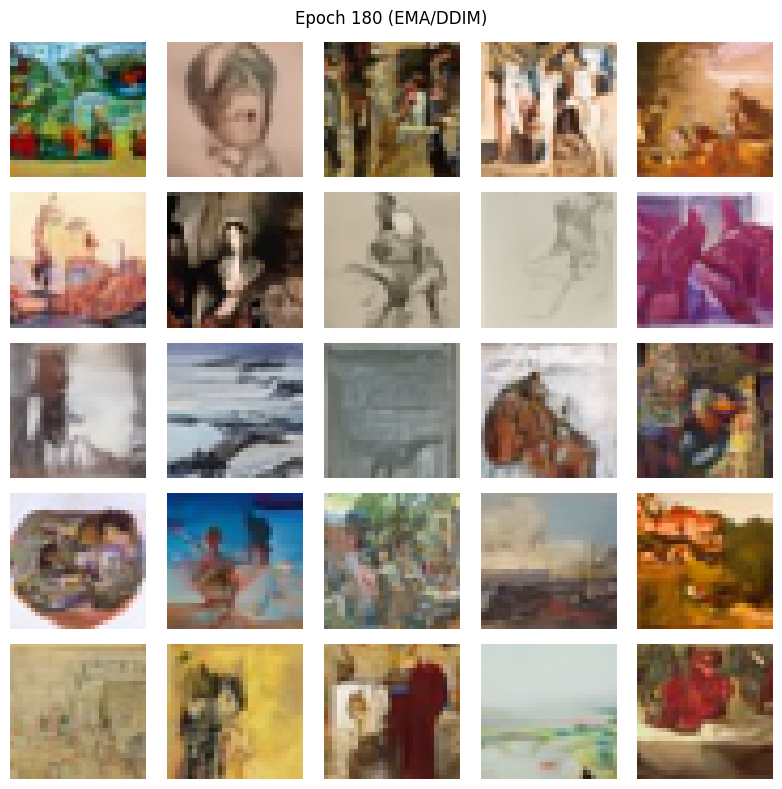

✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_180.pt
Epoch 180/250 | loss: 0.059295 | FID: 46.06


Epoch 181/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 181/250 | loss: 0.059754


Epoch 182/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 182/250 | loss: 0.058553


...

Epoch 188/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 188/250 | loss: 0.059082


Epoch 189/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 189/250 | loss: 0.059622


Epoch 190/250:   0%|          | 0/391 [00:00<?, ?it/s]

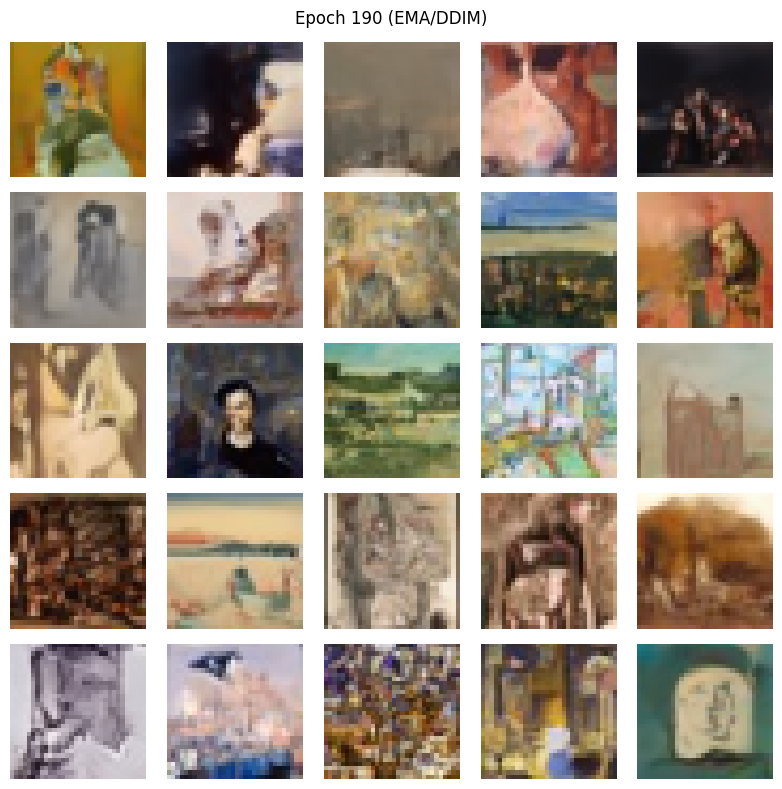

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 44.9901. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_190.pt
Epoch 190/250 | loss: 0.058551 | FID: 44.99


Epoch 191/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 191/250 | loss: 0.059309


Epoch 192/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 192/250 | loss: 0.059176


...

Epoch 198/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 198/250 | loss: 0.058494


Epoch 199/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 199/250 | loss: 0.058790


Epoch 200/250:   0%|          | 0/391 [00:00<?, ?it/s]

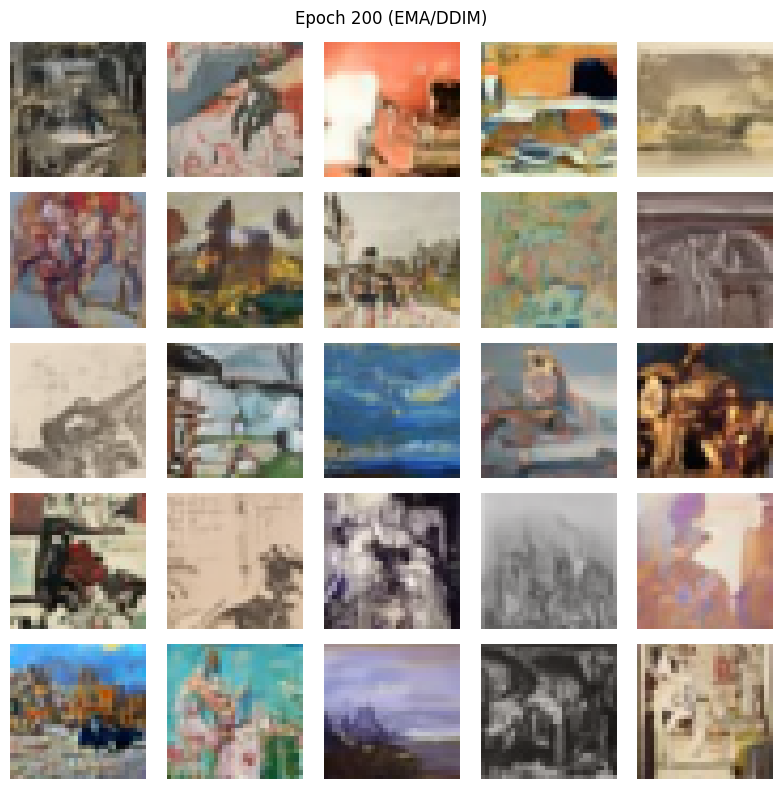

✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_200.pt
Epoch 200/250 | loss: 0.058376 | FID: 45.79


Epoch 201/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 201/250 | loss: 0.058754


Epoch 202/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 202/250 | loss: 0.058609


...

Epoch 208/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 208/250 | loss: 0.058098


Epoch 209/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 209/250 | loss: 0.060154


Epoch 210/250:   0%|          | 0/391 [00:00<?, ?it/s]

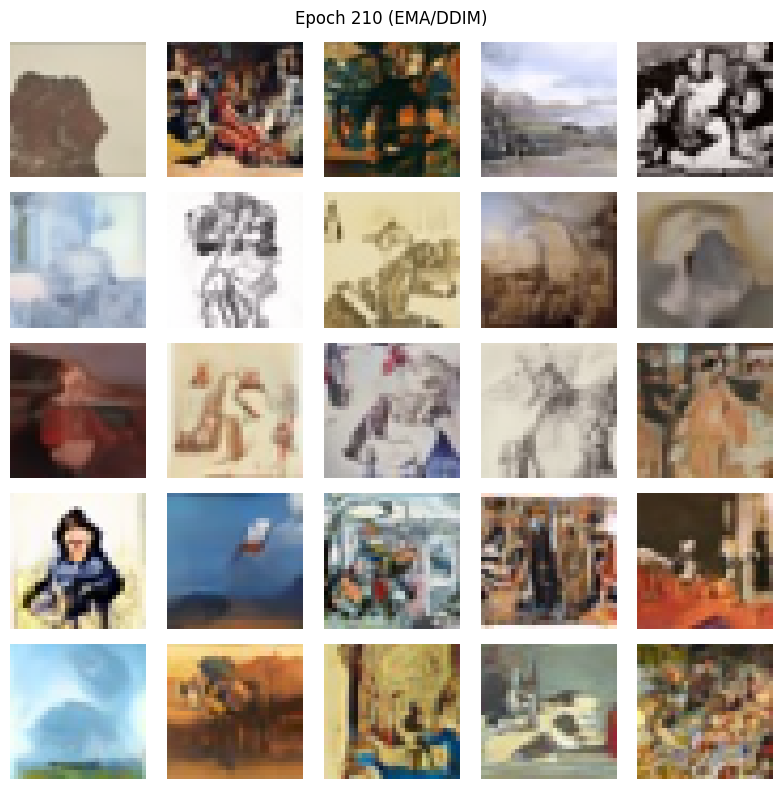

✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_210.pt
Epoch 210/250 | loss: 0.059094 | FID: 45.15


Epoch 211/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 211/250 | loss: 0.059160


Epoch 212/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 212/250 | loss: 0.058962


...

Epoch 218/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 218/250 | loss: 0.059468


Epoch 219/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 219/250 | loss: 0.058643


Epoch 220/250:   0%|          | 0/391 [00:00<?, ?it/s]

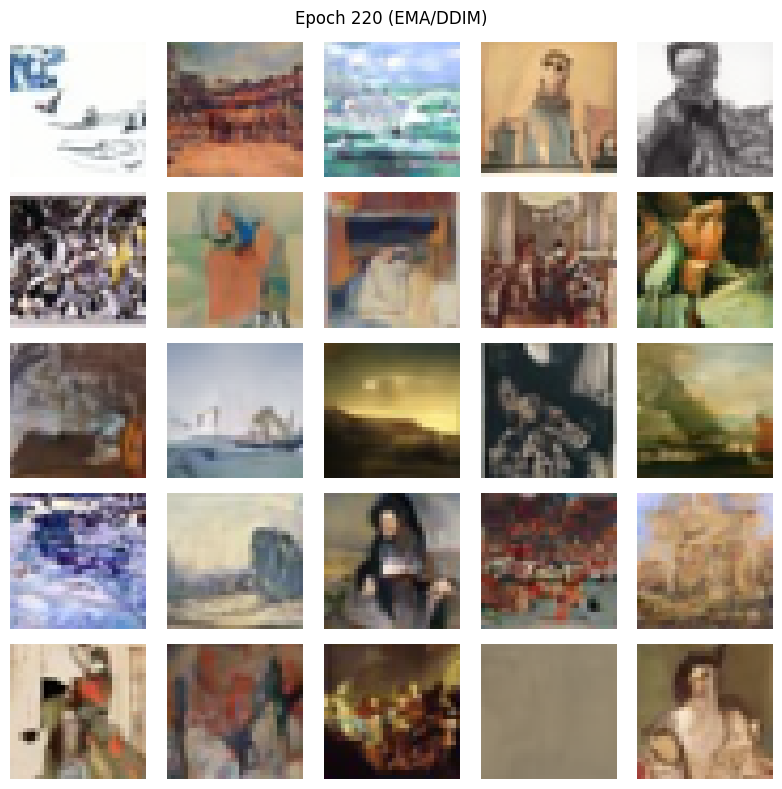

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 44.6857. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_220.pt
Epoch 220/250 | loss: 0.058921 | FID: 44.69


Epoch 221/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 221/250 | loss: 0.058727


Epoch 222/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 222/250 | loss: 0.059035


...

Epoch 228/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 228/250 | loss: 0.058748


Epoch 229/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 229/250 | loss: 0.059368


Epoch 230/250:   0%|          | 0/391 [00:00<?, ?it/s]

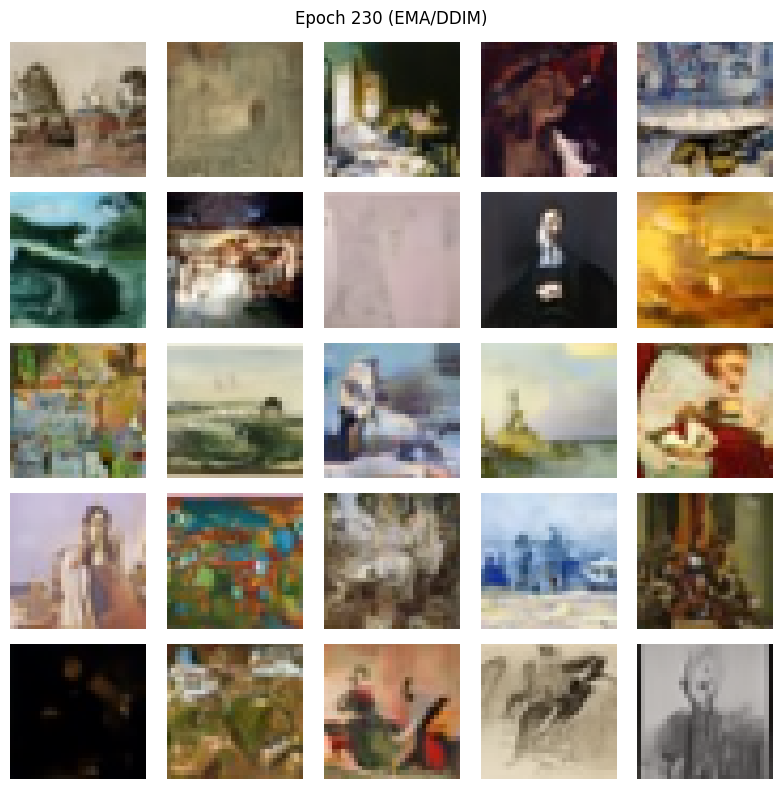

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 44.3626. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_230.pt
Epoch 230/250 | loss: 0.058867 | FID: 44.36


Epoch 231/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 231/250 | loss: 0.059332


Epoch 232/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 232/250 | loss: 0.058705


...

Epoch 238/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 238/250 | loss: 0.058649


Epoch 239/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 239/250 | loss: 0.058350


Epoch 240/250:   0%|          | 0/391 [00:00<?, ?it/s]

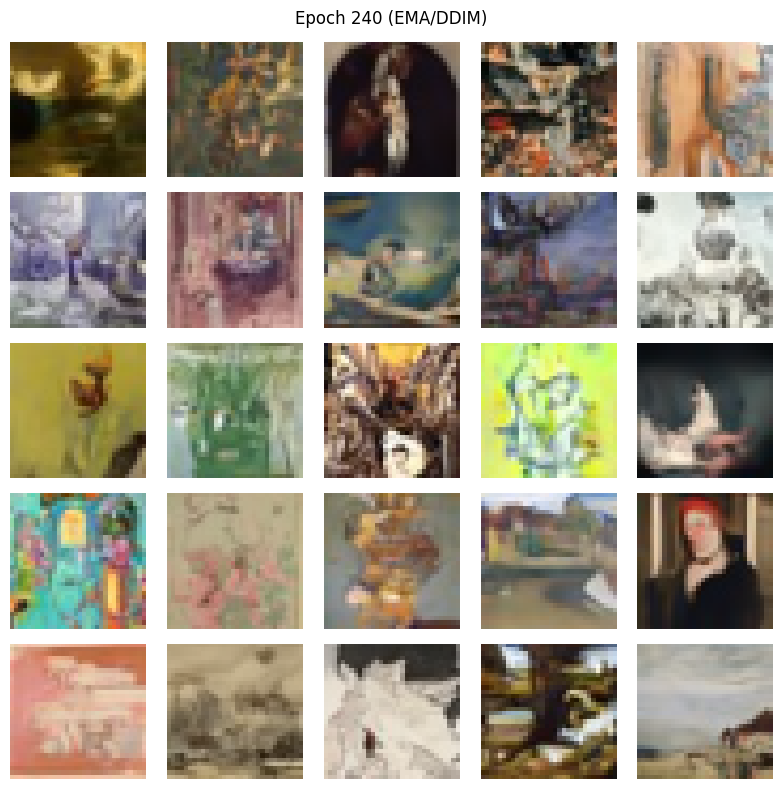

✅ Checkpoint saved to runs\diffusion\final_run\best_fid_model.pt
   -> New best FID: 44.1295. Saved best_fid_model.pt
✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_240.pt
Epoch 240/250 | loss: 0.058996 | FID: 44.13


Epoch 241/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 241/250 | loss: 0.058847


Epoch 242/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 242/250 | loss: 0.058996


...

Epoch 248/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 248/250 | loss: 0.058447


Epoch 249/250:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 249/250 | loss: 0.058788


Epoch 250/250:   0%|          | 0/391 [00:00<?, ?it/s]

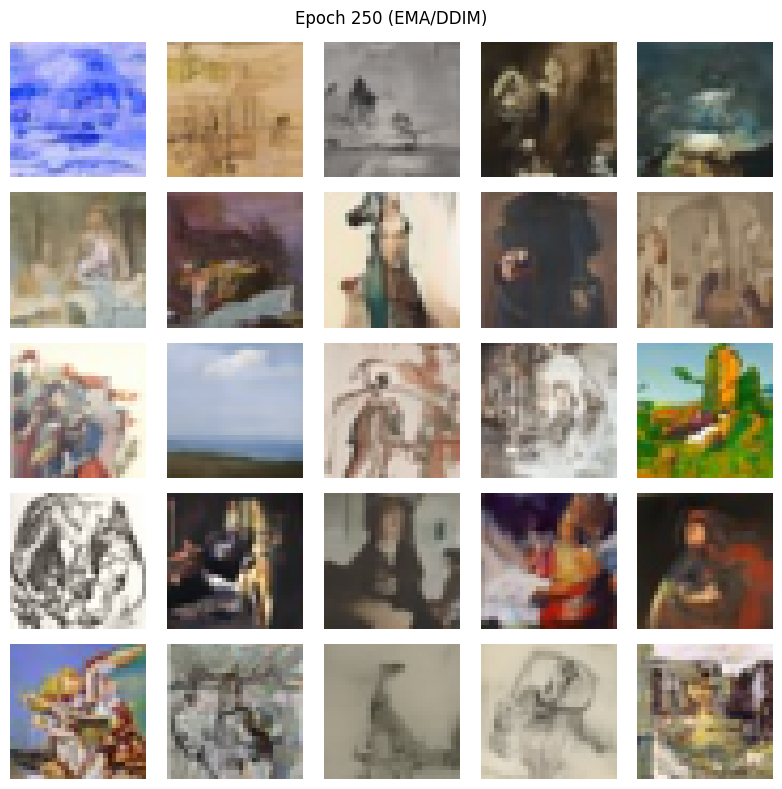

✅ Checkpoint saved to runs\diffusion\final_run\checkpoint_epoch_250.pt
Epoch 250/250 | loss: 0.059053 | FID: 44.26


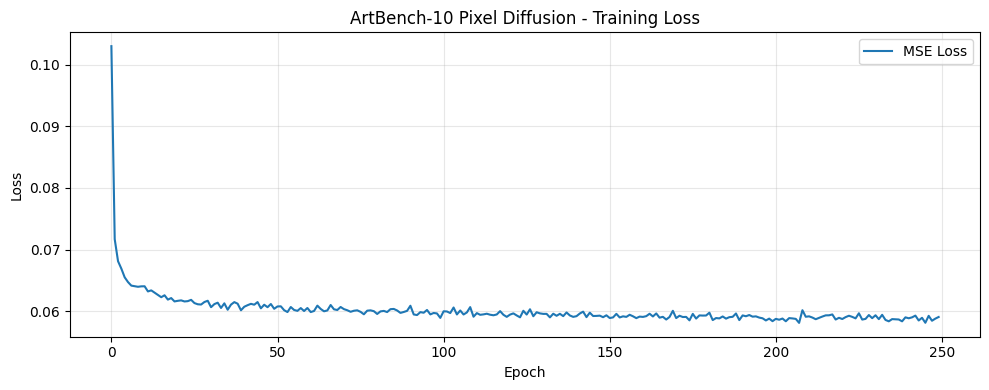

✅ Checkpoint saved to runs\diffusion\artbench_pixel_diffusion.pt


ConnectionError: HTTPSConnectionPool(host='ntfy.sh', port=443): Max retries exceeded with url: /notebookIAGricardo (Caused by NameResolutionError("HTTPSConnection(host='ntfy.sh', port=443): Failed to resolve 'ntfy.sh' ([Errno 11001] getaddrinfo failed)"))

In [9]:
# Train best model with best params from Optuna
# best_params = study.best_params

best_lr = 0.000193
best_channels = 128
best_schedule_type = 'cosine'

best_pixel_model = PixelUNet(in_channels=3, model_channels=best_channels).to(device)
pixel_diffusion = GaussianDiffusion(num_timesteps=1000, beta_schedule=best_schedule_type, device=device)

# --- RE-LOAD FULL DATASET FOR FINAL TRAINING ---
print("Re-loading full ArtBench dataset (50k images)...")
artbench_train_loader_full, _, _, _, _ = build_loaders(
    dataset_name='artbench',
    batch_size=128,
    train_limit=None,
)

model_params = {
    'model_channels': best_channels, 
    'lr': best_lr, 
    'beta_schedule': best_schedule_type
}

history, _, pixel_ema = train_diffusion(
    best_pixel_model, 
    artbench_train_loader_full, 
    pixel_diffusion, 
    epochs=250, 
    lr=best_lr, 
    print_progress=True,
    val_loader=artbench_test_loader,
    checkpoint_dir='runs/diffusion/final_run',
    save_interval=10,
    model_params=model_params
)

# Use EMA model for sampling (better quality)
best_pixel_ema_model = pixel_ema.get_model()

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history['mse_loss'], label='MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ArtBench-10 Pixel Diffusion - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save final checkpoint
save_checkpoint(
    best_pixel_model, pixel_ema, history, 
    'runs/diffusion/artbench_pixel_diffusion.pt', 
    model_params
)



try:
    pass
    notify("✅ Finished successfully!")
except Exception as e:
    notify(f"❌ Failed: {traceback.format_exc()}", title="Notebook Error")

✅ EMA model loaded!
Params: {'model_channels': 128, 'lr': 0.000193, 'beta_schedule': 'cosine'}
Gerando amostras via DDIM (100 steps)...


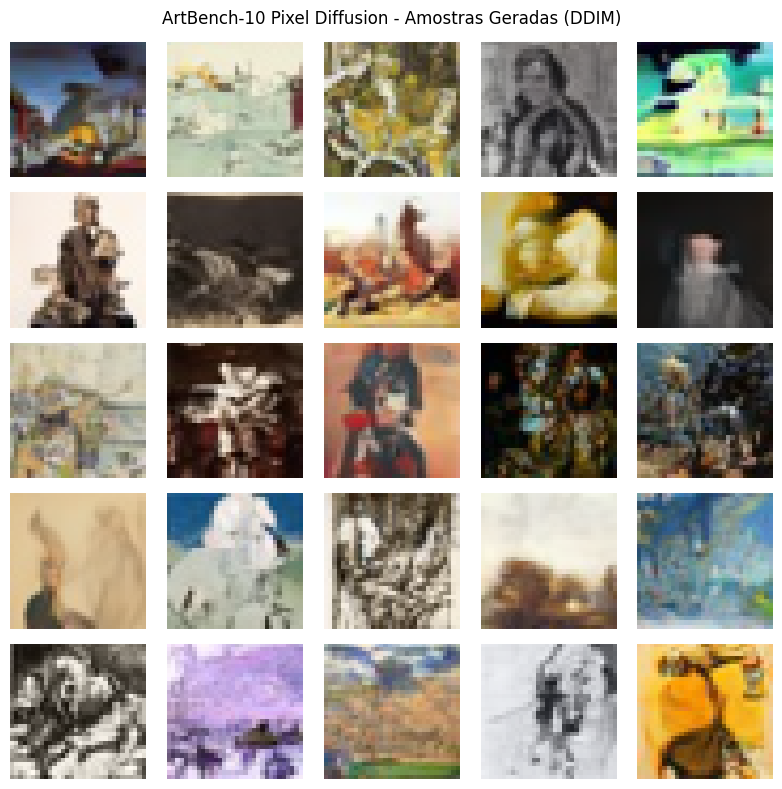


Interpolação entre dois pontos de ruído (DDIM, eta=0)...


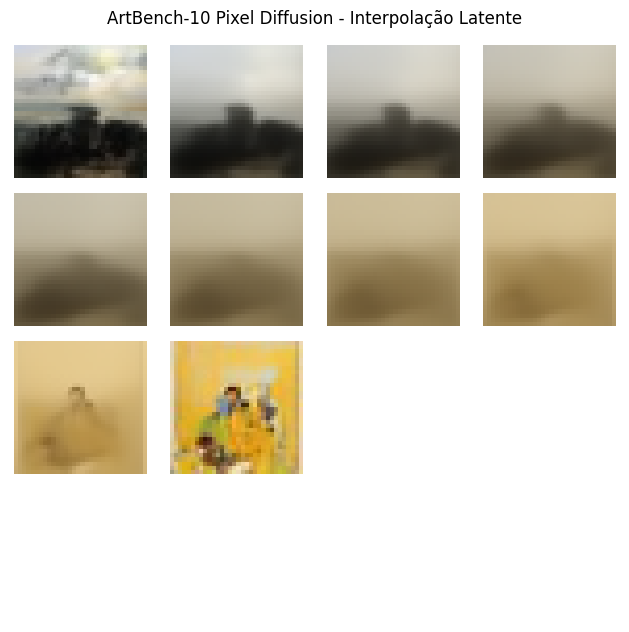

In [24]:
# ==========================================
# 1. CARREGANDO O MODELO TREINADO
# ==========================================
best_ckpt_path = Path('runs/diffusion/final_run/checkpoint_epoch_240.pt')
if best_ckpt_path.exists():
    ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=True)
    loaded_params = ckpt['params']
    loaded_model = PixelUNet(in_channels=3, model_channels=loaded_params['model_channels']).to(device)
    
    
    # Prefer EMA weights if available (better sample quality)
    if 'ema_state' in ckpt:
        loaded_model.load_state_dict(ckpt['ema_state'])
        print("✅ EMA model loaded!")
    else:
        loaded_model.load_state_dict(ckpt['model_state'])
        print("✅ Model loaded (no EMA).")
    loaded_model.eval()
    
    beta_sched = loaded_params.get('beta_schedule', 'cosine')
    loaded_schedule = GaussianDiffusion(num_timesteps=1000, beta_schedule=beta_sched, device=device)
    print(f"Params: {loaded_params}")
else:
    print(f"❌ Checkpoint {best_ckpt_path} not found. Skipping inference.")
    loaded_model = None

# ==========================================
# 2. GERANDO AMOSTRAS (DDIM - faster)
# ==========================================
if loaded_model is not None:
    print("Gerando amostras via DDIM (100 steps)...")
    with torch.no_grad():
        samples = loaded_schedule.ddim_sample_loop(loaded_model, (25, 3, 32, 32), ddim_steps=100)
    show_image_grid(samples, channels=3, title='ArtBench-10 Pixel Diffusion - Amostras Geradas (DDIM)', n_show=25)

    # ==========================================
    # 3. INTERPOLAÇÃO NO ESPAÇO LATENTE (DDIM deterministic)
    # ==========================================
    print("\nInterpolação entre dois pontos de ruído (DDIM, eta=0)...")
    z1 = torch.randn(1, 3, 32, 32, device=device)
    z2 = torch.randn(1, 3, 32, 32, device=device)
    n_interp = 10
    interp_images = []

    for alpha_val in torch.linspace(0, 1, n_interp):
        z_interp = (1 - alpha_val) * z1 + alpha_val * z2
        with torch.no_grad():
            img = loaded_schedule.ddim_sample_loop(
                loaded_model, z_interp.shape, ddim_steps=100, eta=0.0, x_init=z_interp
            )
        interp_images.append(img)

    interp_grid = torch.cat(interp_images, dim=0)
    show_image_grid(interp_grid, channels=3, title='ArtBench-10 Pixel Diffusion - Interpolação Latente', n_show=n_interp)

In [25]:
def run_robust_evaluation(model, schedule, dataloader, device, num_runs=10, use_ddim=True, ddim_steps=100):
    fids, kids = [], []
    print(f"Starting robust evaluation ({num_runs} runs)...")
    for i in range(num_runs):
        print(f"\n--- Starting Run {i+1}/{num_runs} ---")
        set_seed(100 + i)
        f, k, _ = evaluate_metrics(model, schedule, dataloader, device, use_ddim=use_ddim, ddim_steps=ddim_steps)
        fids.append(f)
        kids.append(k)
        print(f"Run {i+1}/{num_runs} Completed | FID: {f:.4f} | KID: {k:.4f}")
    
    print("\n" + "="*30)
    print(f"FINAL RESULTS ({num_runs} Runs):")
    print(f"FID: {np.mean(fids):.4f} ± {np.std(fids):.4f}")
    print(f"KID: {np.mean(kids):.4f} ± {np.std(kids):.4f}")
    print("="*30)

In [ ]:
import torch
from pathlib import Path

# Load the history from the final checkpoint
ckpt_path = Path('runs/diffusion/artbench_pixel_diffusion.pt')
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
    history = ckpt.get('history', {})
    
    print("Training MSE Loss:", history.get('mse_loss', []))
    print("\nFID/KID History:")
    for entry in history.get('fid', []):
        print(f"Epoch {entry['epoch']}: FID={entry['fid']:.4f}, KID={entry['kid']:.4f}")

#print best FID and corresponding epoch
best_fid_entry = min(history.get('fid', []), key=lambda x: x['fid'], default=None)
if best_fid_entry:
    print(f"\nBest FID: {best_fid_entry['fid']:.4f} at Epoch {best_fid_entry['epoch']}")
    

Training MSE Loss: [0.10297943577360924, 0.07167118237070415, 0.06810140048565767, 0.06689267788472993, 0.06549070154309578, 0.06471753079453697, 0.06414172843174862, 0.06405115484848352, 0.0639543259502067, 0.06402473249818053, 0.06403524138014335, 0.06319904986702268, 0.06336992821844338, 0.06299621829062776, 0.0626028055691963, 0.06226406920977565, 0.06257645358019473, 0.061872389300933577, 0.06212239223711021, 0.06157898251205454, 0.061678134629031274, 0.06174870341292123, 0.06157426096861015, 0.061624965932972904, 0.06183542223537669, 0.061310502145525136, 0.06111687544704703, 0.061074984881579114, 0.0614827407138122, 0.061687915755049956, 0.06064393396115364, 0.061146297932738236, 0.0613729221474789, 0.06051946794399825, 0.06126906179711032, 0.060229205223910336, 0.061061957655736555, 0.06146638451710991, 0.06121011549020972, 0.06014366970990625, 0.0607163714687995, 0.06096908533969499, 0.06118778790087651, 0.06104659295790946, 0.0614749506173079, 0.060461380292692456, 0.06104228

In [27]:
if best_ckpt_path.exists():
    ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=True)
    params = ckpt['params']

    eval_model = PixelUNet(in_channels=3, model_channels=params['model_channels']).to(device)
    eval_model.load_state_dict(ckpt['ema_state'])
    eval_model.eval()

    pixel_diffusion = GaussianDiffusion(num_timesteps=1000, beta_schedule=params['beta_schedule'], device=device)

    run_robust_evaluation(eval_model, pixel_diffusion, artbench_test_loader, device, use_ddim=True, ddim_steps=100)

Starting robust evaluation (10 runs)...

--- Starting Run 1/10 ---


c:\Users\ricar\OneDrive\Desktop\Curso\IAG\Projeto\artbench\genai-env\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Run 1/10 Completed | FID: 19.8290 | KID: 0.0060

--- Starting Run 2/10 ---
Run 2/10 Completed | FID: 19.8074 | KID: 0.0063

--- Starting Run 3/10 ---
Run 3/10 Completed | FID: 20.0756 | KID: 0.0065

--- Starting Run 4/10 ---
Run 4/10 Completed | FID: 19.7950 | KID: 0.0061

--- Starting Run 5/10 ---
Run 5/10 Completed | FID: 19.4736 | KID: 0.0059

--- Starting Run 6/10 ---
Run 6/10 Completed | FID: 19.9082 | KID: 0.0067

--- Starting Run 7/10 ---
Run 7/10 Completed | FID: 19.7716 | KID: 0.0062

--- Starting Run 8/10 ---
Run 8/10 Completed | FID: 19.7055 | KID: 0.0063

--- Starting Run 9/10 ---
Run 9/10 Completed | FID: 19.5670 | KID: 0.0062

--- Starting Run 10/10 ---
Run 10/10 Completed | FID: 19.9342 | KID: 0.0067

FINAL RESULTS (10 Runs):
FID: 19.7867 ± 0.1659
KID: 0.0063 ± 0.0002
